In [1]:
# 1. Import Library dn Load dataset CSV
import pandas as pd
df = pd.read_csv("Dataset_Cw_NoLabel.csv")

In [2]:
# 2. Fungsi rule-based labeling
def tentukan_label(row):
    if (
        8 <= row["pH"] <= 11 and
        0 <= row["SC"] <= 6000 and
        500 <= row["Nitrite"] <= 1500 and
        0 <= row["Fe"] <= 1 and
        0 <= row["Sulfate"] <= 100 and
        0 <= row["Turbidity"] <= 30
    ):
        return "Layak"
    else:
        return "Tidak Layak"

In [3]:
# 3. Tambahkan kolom target
df["Target"] = df.apply(tentukan_label, axis=1)

In [4]:
# 4. Encoding label
df["Target_encoded"] = df["Target"].map({
    "Tidak Layak": 0,
    "Layak": 1
})

In [5]:
# 5. Simpan dataset baru CSV
df.to_csv("Dataset_CoolingWater.csv", index=False)

print("Selesai! Dataset berhasil dilabeli.")

Selesai! Dataset berhasil dilabeli.


In [6]:
# 6. CEK JUMLAH DATA TIAP KELAS
print("\nJumlah tiap kelas:")
print(df["Target"].value_counts())


Jumlah tiap kelas:
Target
Layak          958
Tidak Layak     98
Name: count, dtype: int64


In [7]:
# 7. CEK PERSENTASE DISTRIBUSI KELAS
print("\nPersentase tiap kelas:")
print(df["Target"].value_counts(normalize=True) * 100)


Persentase tiap kelas:
Target
Layak          90.719697
Tidak Layak     9.280303
Name: proportion, dtype: float64


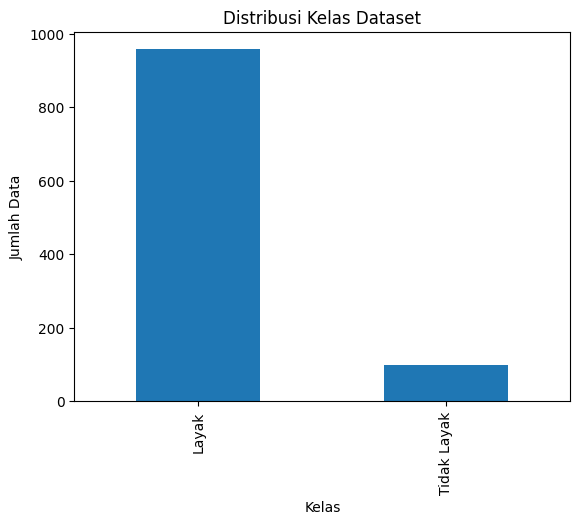

In [8]:
# 8. VISUALISASI DISTRIBUSI KELAS
import matplotlib.pyplot as plt

df["Target"].value_counts().plot(kind="bar")

plt.title("Distribusi Kelas Dataset")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")

plt.show()